In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random


In [2]:
from nn_interpretation.signal_generator import signal_generator

num_instances = 10000
start = 0
end = 32.0
step = 0.2
noise_sigma = 0.1

x_data, y_data, signal_length = signal_generator(num_instances=num_instances, start=start, end=end, step=step, noise_sigma=noise_sigma)

In [3]:
import torch
import torch.nn as nn

class net_3_layers(nn.Module):
    def __init__(self):
        super(net_3_layers, self).__init__()
        # Hidden layers (from previous step)
        self.fc1 = nn.Linear(signal_length, signal_length, bias=False)
        self.fc2 = nn.Linear(signal_length, signal_length, bias=False)
        self.fc3 = nn.Linear(signal_length, signal_length, bias=False)
        
        # New Regression Layer
        # Maps from the hidden signal_length to the desired number of continuous outputs
        self.regressor = nn.Linear(signal_length, signal_length, bias=True)

    def forward(self, x):
        # Hidden Layer 1
        x = self.fc1(x)
        x = torch.tanh(x) 
        
        # Hidden Layer 2
        x = self.fc2(x)
        x = torch.tanh(x) 

        # Hidden Layer 3
        x = self.fc3(x)
        x = torch.tanh(x)
        
        # Regression Layer (No activation function here)
        x = self.regressor(x)
        
        return x

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_3_layers = net_3_layers().to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_3_layers.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model_3_layers.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:102560
160


In [5]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_3_layers(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0029
Epoch [100/1000], Loss: 0.0132
Epoch [150/1000], Loss: 0.0020
Epoch [200/1000], Loss: 0.0024
Epoch [250/1000], Loss: 0.0013
Epoch [300/1000], Loss: 0.0012
Epoch [350/1000], Loss: 0.0010
Epoch [400/1000], Loss: 0.0009
Epoch [450/1000], Loss: 0.0008
Epoch [500/1000], Loss: 0.0007
Epoch [550/1000], Loss: 0.0007
Epoch [600/1000], Loss: 0.0008
Epoch [650/1000], Loss: 0.0008
Epoch [700/1000], Loss: 0.0007
Epoch [750/1000], Loss: 0.0006
Epoch [800/1000], Loss: 0.0006
Epoch [850/1000], Loss: 0.0007
Epoch [900/1000], Loss: 0.0006
Epoch [950/1000], Loss: 0.0006
Epoch [1000/1000], Loss: 0.0006


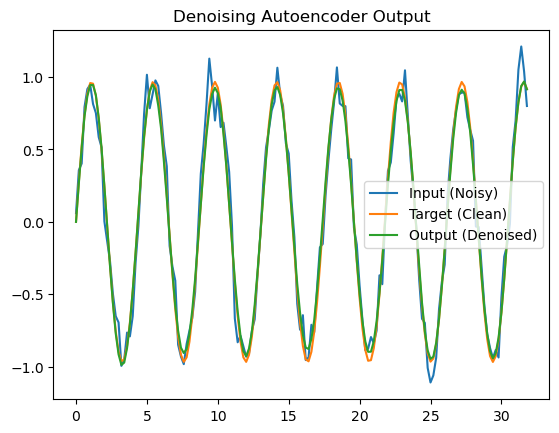

In [7]:
idx = 4
input = x_data[idx].unsqueeze(0)
target = y_data[idx].unsqueeze(0)
output = model_3_layers(input)

# Convert tensors to ndarrays
input_np = input.cpu().detach().numpy()
target_np = target.cpu().detach().numpy()
output_np = output.cpu().detach().numpy()
x = np.arange(0, 32, 0.2).reshape(1, -1)
# Plotting
plt.figure()
plt.plot(x.T, input_np[0], label='Input (Noisy)')
plt.plot(x.T, target_np[0], label='Target (Clean)')
plt.plot(x.T, output_np[0], label='Output (Denoised)')
plt.legend()
plt.title('Denoising Autoencoder Output')
plt.show()

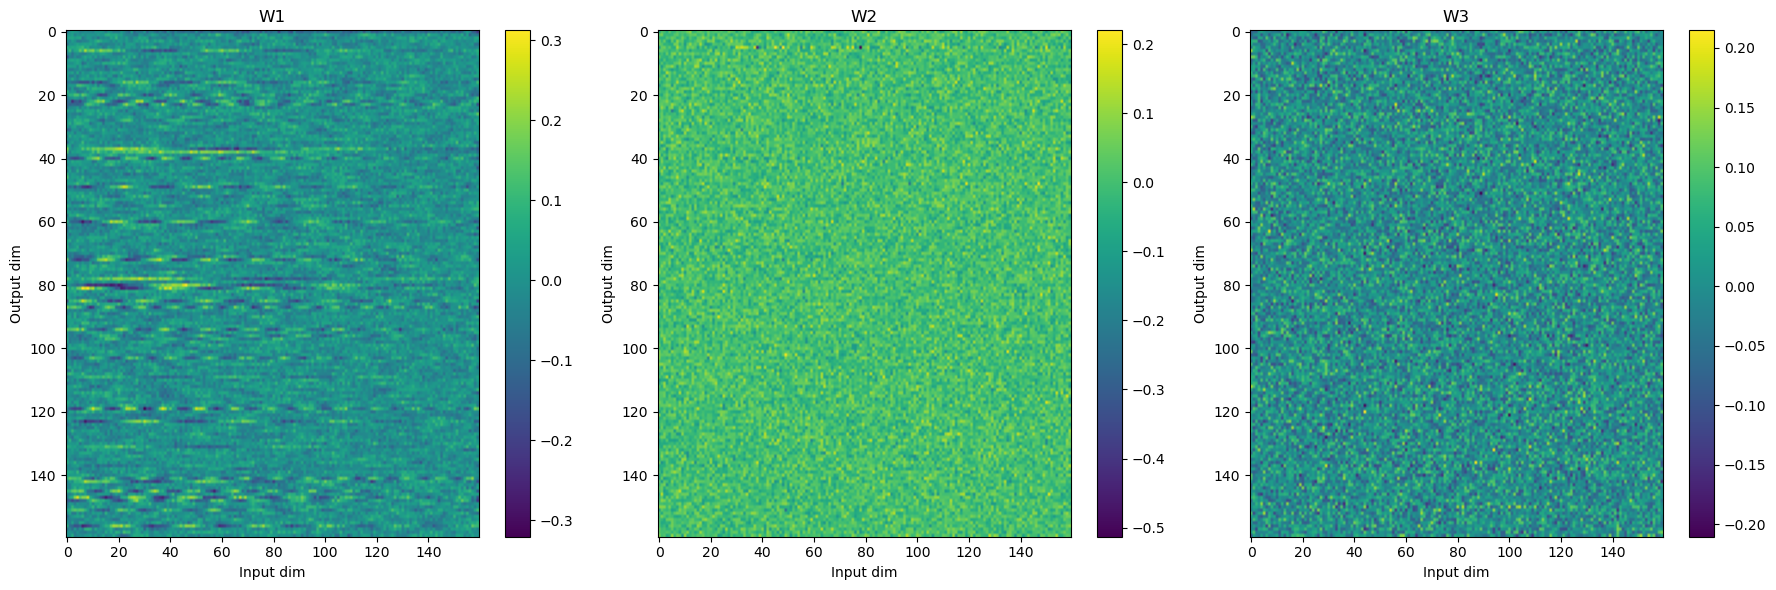

In [10]:
W1 = model_3_layers.fc1.weight.data
W1= W1.cpu().detach().numpy()

W2 = model_3_layers.fc2.weight.data
W2 = W2.cpu().detach().numpy()

W3 = model_3_layers.fc3.weight.data
W3 = W3.cpu().detach().numpy() 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, W, title in zip(
    axes,
    [W1, W2, W3],
    ['W1', 'W2', 'W3']
):
    im = ax.imshow(W, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Input dim')
    ax.set_ylabel('Output dim')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [11]:
from nn_interpretation.descramble import descramble

In [12]:
S = W1 @ x_data.cpu().detach().numpy().T
P, Q = descramble(S, n_iter=1000)

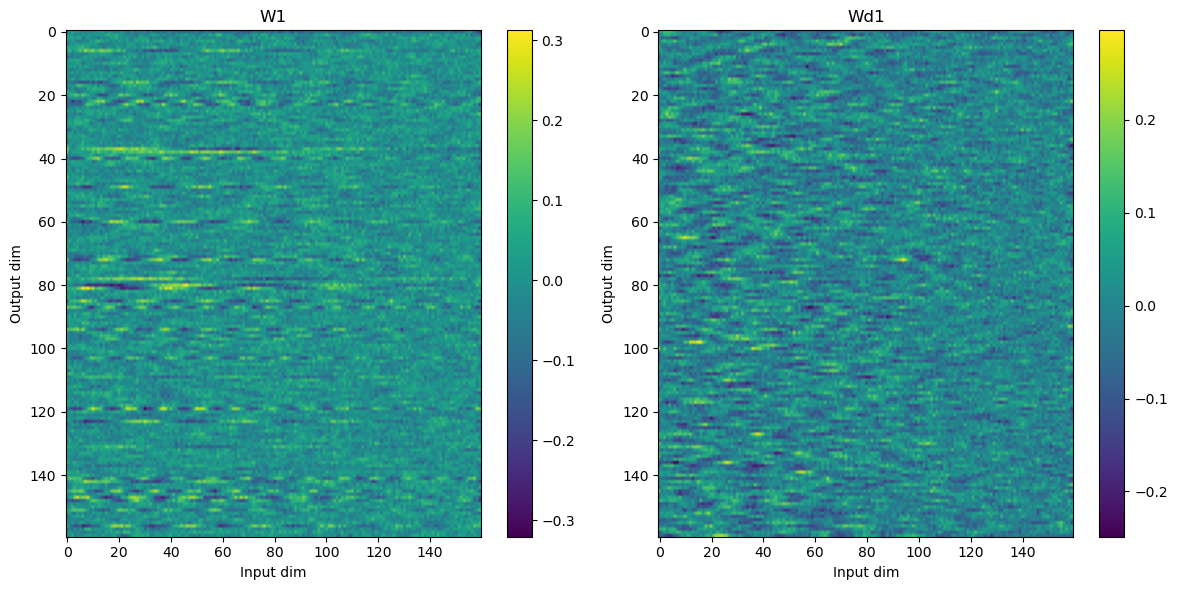

In [33]:
Wd1 = P@W1


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, W, title in zip(
    axes,
    [W1, Wd1],
    ['W1', 'Wd1']
):
    im = ax.imshow(W, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Input dim')
    ax.set_ylabel('Output dim')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [15]:
# Convert Wd to a PyTorch tensor on the same device as x_data
Wd1_tensor = torch.from_numpy(Wd1).float().to(device)

# Apply Wd transformation followed by tanh activation
subnet_1_data = torch.tanh(x_data @ Wd1_tensor.T)

In [16]:
class net_2_layers(nn.Module):
    def __init__(self):
        super(net_2_layers, self).__init__()
        # Hidden layers (from previous step)
        self.fc1 = nn.Linear(signal_length, signal_length, bias=False)
        self.fc2 = nn.Linear(signal_length, signal_length, bias=False)
        
        # New Regression Layer
        # Maps from the hidden signal_length to the desired number of continuous outputs
        self.regressor = nn.Linear(signal_length, signal_length, bias=True)

    def forward(self, x):
        # Hidden Layer 1
        x = self.fc1(x)
        x = torch.tanh(x) 
        
        # Hidden Layer 2
        x = self.fc2(x)
        x = torch.tanh(x) 
        
        # Regression Layer (No activation function here)
        x = self.regressor(x)
        
        return x

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_2_layers = net_2_layers().to(device)
subnet_1_data = subnet_1_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_2_layers.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model_2_layers.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:76960
160


In [18]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_2_layers(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0023
Epoch [100/1000], Loss: 0.0018
Epoch [150/1000], Loss: 0.0015
Epoch [200/1000], Loss: 0.0011
Epoch [250/1000], Loss: 0.0010
Epoch [300/1000], Loss: 0.0009
Epoch [350/1000], Loss: 0.0009
Epoch [400/1000], Loss: 0.0008
Epoch [450/1000], Loss: 0.0007
Epoch [500/1000], Loss: 0.0007
Epoch [550/1000], Loss: 0.0007
Epoch [600/1000], Loss: 0.0006
Epoch [650/1000], Loss: 0.0007
Epoch [700/1000], Loss: 0.0007
Epoch [750/1000], Loss: 0.0006
Epoch [800/1000], Loss: 0.0007
Epoch [850/1000], Loss: 0.0006
Epoch [900/1000], Loss: 0.0005
Epoch [950/1000], Loss: 0.0005
Epoch [1000/1000], Loss: 0.0005


In [19]:
W1_sub = model_2_layers.fc1.weight.data
W1_sub= W1_sub.cpu().detach().numpy()

In [20]:
S_2 = W1_sub @ subnet_1_data.cpu().detach().numpy().T
P, Q = descramble(S_2, n_iter=1000)

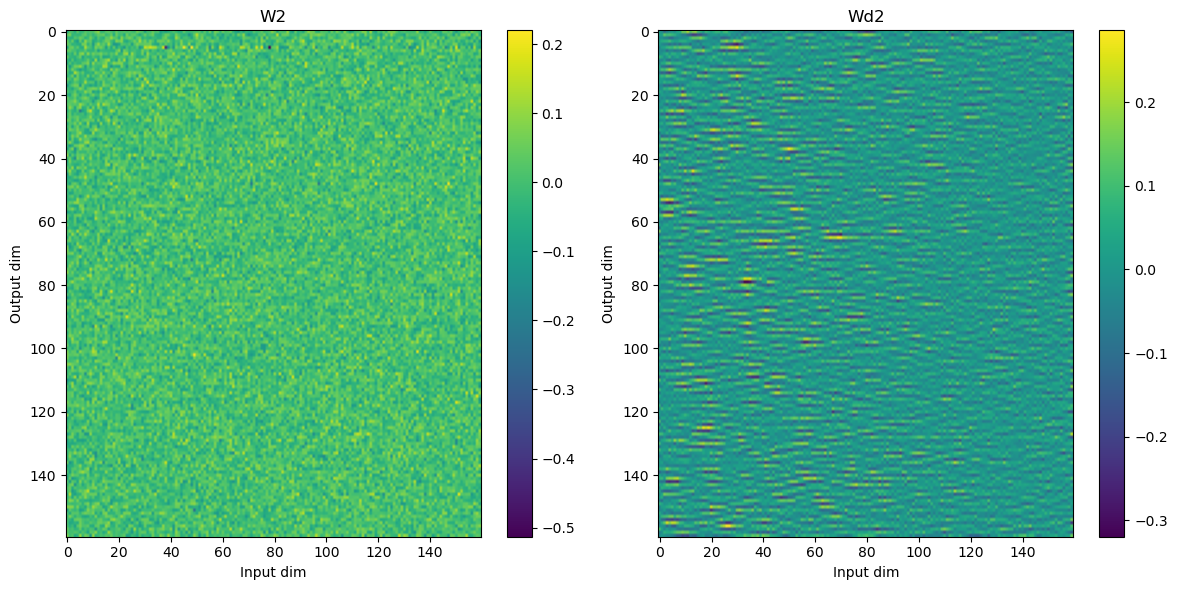

In [34]:
Wd2 = P@W1_sub

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, W, title in zip(
    axes,
    [W2, Wd2],
    ['W2', 'Wd2']
):
    im = ax.imshow(W, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Input dim')
    ax.set_ylabel('Output dim')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [22]:
# Convert Wd to a PyTorch tensor on the same device as x_data
Wd2_tensor = torch.from_numpy(Wd2).float().to(device)

# Apply Wd transformation followed by tanh activation
subnet_2_data = torch.tanh(subnet_1_data @ Wd2_tensor.T)

In [23]:
class subnet(torch.nn.Module):

    def __init__(self):
        super(subnet, self).__init__()
        # Single hidden layer with no bias
        self.fc = nn.Linear(signal_length,signal_length, bias = False)

    def forward(self,x):
      x = self.fc(x)
      return x

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = subnet().to(device)
subnet_2_data = subnet_2_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:25600
160


In [27]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(subnet_2_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0086
Epoch [100/1000], Loss: 0.0069
Epoch [150/1000], Loss: 0.0062
Epoch [200/1000], Loss: 0.0057
Epoch [250/1000], Loss: 0.0054
Epoch [300/1000], Loss: 0.0052
Epoch [350/1000], Loss: 0.0050
Epoch [400/1000], Loss: 0.0048
Epoch [450/1000], Loss: 0.0047
Epoch [500/1000], Loss: 0.0046
Epoch [550/1000], Loss: 0.0045
Epoch [600/1000], Loss: 0.0044
Epoch [650/1000], Loss: 0.0044
Epoch [700/1000], Loss: 0.0043
Epoch [750/1000], Loss: 0.0042
Epoch [800/1000], Loss: 0.0042
Epoch [850/1000], Loss: 0.0042
Epoch [900/1000], Loss: 0.0041
Epoch [950/1000], Loss: 0.0041
Epoch [1000/1000], Loss: 0.0040


In [28]:
W_subnet_2 = model.fc.weight.data
W_subnet_2 = W_subnet_2.cpu().detach().numpy()

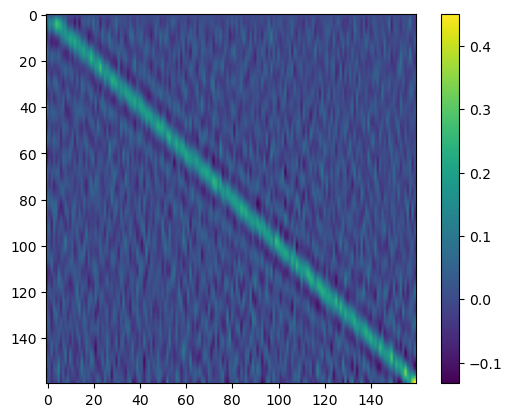

In [30]:
plt.imshow(W_subnet_2@Wd2@Wd1)
plt.colorbar()
plt.show()